### Basic Anomaly Detection (tensorflow version)) of Financial Time Series Data using an Autoencoder
References:
- [Susan Li, "Time Series of Price Anomaly Detection with LSTM" in Medium 2020](https://medium.com/data-science/time-series-of-price-anomaly-detection-with-lstm-11a12ba4f6d9)
- [DigitalSreeni, "180 - LSTM Autoencoder for anomaly detection", Youtube Video](https://www.youtube.com/watch?v=6S2v7G-OupA)

### Imports

In [1]:
import numpy as np
import yfinance as yf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Input, Dropout
from keras.layers import Dense
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
import pandas as pd
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Model
import seaborn as sns
from dataclasses import dataclass
from enum import Enum
from typing import Tuple
import os

%matplotlib inline

### Define Configurations

In [2]:
TOP_10_TECH_TICKERS = ["NVDA","AAPL","GOOGL", "MSFT", "AMZN", "TSM", "AVGO", "META", "TSLA", "ASML"]
STOCKS_IMAPACTED_BY_COVID = ["DAL", "UAL", "AAL", "LUV", "APA", "OXY", "CCL", "NCLH", "HLT", "EXPE"]

@dataclass
class Config:
    ticker: str = STOCKS_IMAPACTED_BY_COVID[4]
    start_date: str = '2015-03-11'
    end_date: str = '2024-03-11'
    covidemic_start_date: str = '2020-03-11'
    test_start_date: str = '2020-01-02'
    validation_factor: float = 0.2
    sequence_length: int = 30
    hidden_dim_1: int = 64
    hidden_dim_2: int = 32
    latent_dim: int = 4
    batch_size: int = 32
    num_epochs: int = 50
    learning_rate: float = 0.001
    is_persist_data: bool = True
    data_folder: str = 'data'
    
config = Config()

### Define enums

In [3]:
class ThresholdMethod(Enum):
    MAX = 'max'
    PERCENTILE_90 = 'percentile_90'
    THREE_SIGMA = 'three_sigma'

### Data processing:
- Get the data
- Scale the data
- Create data moving window

In [4]:
def load_data(ticker: str, start_date: str, end_date: str, config: Config = config) -> np.ndarray:
    """
    Load historical stock price data for a given ticker and date range.
    :param ticker: Stock ticker symbol (e.g., 'AAPL' for Apple Inc.)
    :param start_date: Start date for data in 'YYYY-MM-DD' format   
    :param end_date: End date for data in 'YYYY-MM-DD' format
    :param config: Configuration object containing settings for data loading    
    :return: Numpy array of closing prices   
    """
    os.makedirs(config.data_folder, exist_ok=True)
    if config.is_persist_data:
        file_path = f"{config.data_folder}/{ticker}_{start_date}_{end_date}.csv"
        if os.path.exists(file_path):
            print(f"Loading data from {file_path}")
            # Skip metadata rows (Ticker and Date header rows) and use first column as date index
            data_df = pd.read_csv(file_path, skiprows=[1, 2], index_col=0, parse_dates=True)
            data_df.index.name = 'Date'
            return data_df['Close'].values.reshape(-1, 1), data_df
    print(f"Downloading data for {ticker} from {start_date} to {end_date}")
    data_df = yf.download(ticker, start=start_date, end=end_date)
    if config.is_persist_data:
        data_df.to_csv(f"{config.data_folder}/{ticker}_{start_date}_{end_date}.csv")    
    return data_df['Close'].values.reshape(-1, 1), data_df

def split_train_test(data_df: pd.DataFrame, split_date: str):
    """
    Split the data into training and testing sets based on a specified date.
    :param data_df: DataFrame containing the stock price data
    :param split_date: Date to split the data into training and testing sets
    :return: Tuple of (training data, testing data)
    """
    split_idx = data_df.index.get_loc(pd.Timestamp(split_date))
    prices = data_df['Close'].values.reshape(-1, 1)
    train_data = prices[:split_idx]
    test_data = prices[split_idx:]
    return train_data, test_data

def scale_data(train_data: np.ndarray, test_data: np.ndarray):
    """
    Scale training and testing data using MinMaxScaler fitted on training data.
    :param train_data: Training data array
    :param test_data: Testing data array
    :return: Tuple of (scaled training data, scaled testing data, fitted scaler)
    """
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    return train_scaled, test_scaled, scaler

def create_sequences(data, seq_len=config.sequence_length) -> np.ndarray:
    """Create sequences of data for training the model.
    :param data: Numpy array of scaled data
    :param seq_len: Length of each sequence
    :return: Numpy array of sequences
    """
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)


def preprocess_data(data: np.ndarray, sequence_length: int) -> (np.ndarray, MinMaxScaler):
    """
    Preprocess the data by normalizing and creating sequences.
    :param data: Numpy array of closing prices
    :param sequence_length: Length of each input sequence for the model
    :return: Tuple of (input sequences as torch.Tensor, fitted MinMaxScaler)
    """
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    
    sequences = []
    for i in range(len(scaled_data) - sequence_length):
        sequences.append(scaled_data[i:i+sequence_length])
    
    return torch.tensor(sequences, dtype=torch.float32), scaler

In [5]:
data, data_df = load_data(config.ticker, config.start_date, config.end_date)
train_data, test_data = split_train_test(data_df, config.test_start_date)
train_scaled, test_scaled, scaler = scale_data(train_data, test_data) 
X_train = create_sequences(train_scaled, config.sequence_length)
X_test = create_sequences(test_scaled, config.sequence_length)

data_df.head()

C:\Users\ADE\AppData\Local\Temp\ipykernel_24748\1701104162.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,APA,APA,APA,APA,APA
Date,,,,,
2015-03-11,46.634472,46.863221,45.620349,45.894846,3452500
2015-03-12,45.879597,46.931847,45.803348,46.916597,3322300
2015-03-13,45.261967,45.383966,44.377467,45.338215,3565500
2015-03-16,45.620350,51.087470,43.897099,44.796849,3817700
2015-03-17,45.056091,45.566965,44.720593,45.383966,2412500


In [6]:
X_train.shape

(1182, 30, 1)

### Visualize the dataset

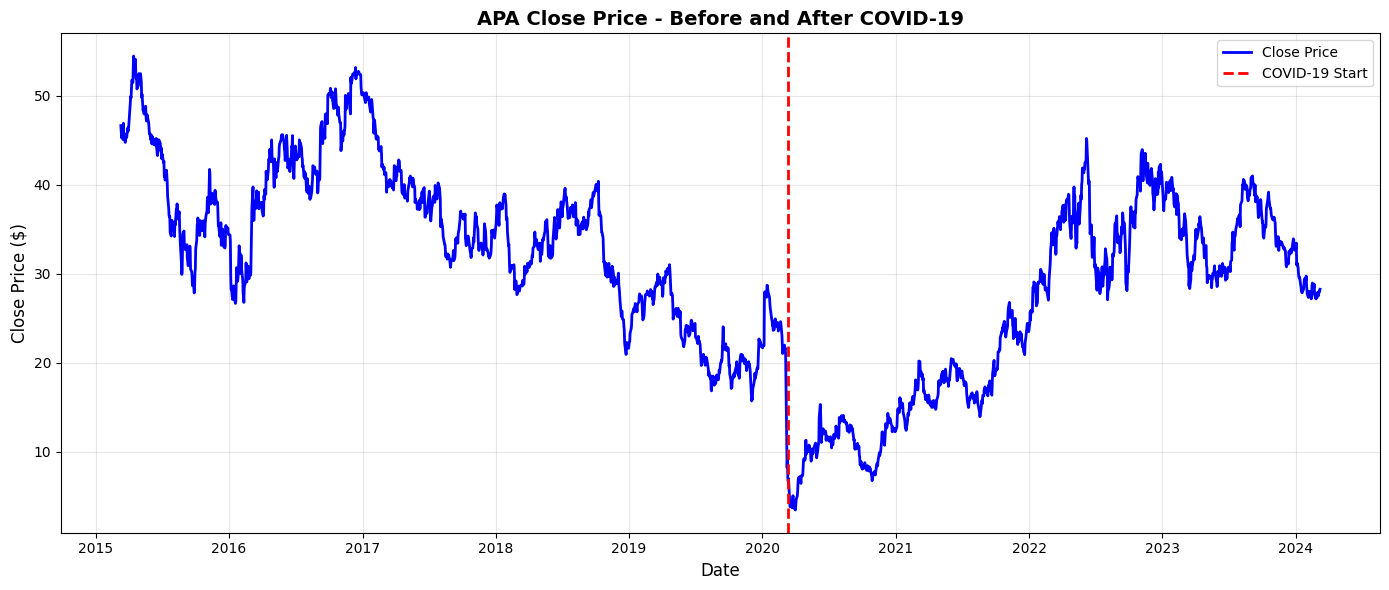

In [7]:
def visualize_close_price(data_df: pd.DataFrame, covid_start_date: str, config: Config):
    """
    Visualize the close price over time with annotation for COVID-19 event.
    :param data_df: DataFrame containing the stock price data
    :param covid_start_date: Date when COVID-19 started
    :param config: Configuration object containing settings
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(data_df.index, data_df['Close'], linewidth=2, color='blue', label='Close Price')
    
    covid_date = pd.to_datetime(covid_start_date)
    ax.axvline(x=covid_date, color='red', linestyle='--', linewidth=2, label='COVID-19 Start')
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Close Price ($)', fontsize=12)
    ax.set_title(f'{config.ticker} Close Price - Before and After COVID-19', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

visualize_close_price(data_df, config.covidemic_start_date, config)

### Define Autoencoder
- An autoencoder is composed of an encoder / decoder blocks and a middle latent ("bottleneck") dimension layer
- Due to the time-series nature of our data set the autoencoder encoder/decoder blocks  will be consist of LSTM layers

In [8]:
class LSTMAutoencoder:
    def __init__(self, config: Config): 
        self.config = config
        self.model = self.build_model()
    
    def build_model(self) -> Model:
        """
        Build the LSTM Autoencoder model architecture.
        :return: Compiled Keras Model
        """
        model = Sequential()
        model.add(LSTM(self.config.hidden_dim_1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(self.config.hidden_dim_2, activation='relu', return_sequences=False))
        model.add(Dropout(0.2))
        model.add(RepeatVector(self.config.sequence_length))
        model.add(LSTM(self.config.hidden_dim_2, activation='relu', return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(self.config.hidden_dim_1, activation='relu', return_sequences=True))
        model.add(Dropout(0.2))
        model.add(TimeDistributed(Dense(1)))
        
        model.compile(optimizer='adam', loss='mae')
        return model

    

#### Visualize the model

In [9]:
autoencoder_model = LSTMAutoencoder(config)
autoencoder_model.model.summary()

c:\Users\ADE\miniconda3\envs\ai-thursdays-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,529 (244.25 KB)

 Trainable params: 62,529 (244.25 KB)

 Non-trainable params: 0 (0.00 B)

### Specify the Anomaly Detector

In [10]:
class AnomalyDetector:
    """
    Anomaly Detector based on a LSTM-Autoencoder model
    """
    def __init__(
        self, 
        config: Config, 
        X_train: np.ndarray, 
        X_test: np.ndarray):
        """
        Initialize the AnomalyDetector with the given configuration.
        :param config: Config object containing hyperparameters such as sequence length, hidden dimensions, latent dimension, batch size, number of epochs, and learning rate.
        """
        self.config = config
        self.autoencoder = LSTMAutoencoder(config)
        self.X_train = X_train
        self.X_test = X_test
        self.callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, mode='min')]

    def fit(self):
        """
        Train the LSTM Autoencoder model on the training data.
        :param X_train: Numpy array of training sequences
        """
        history = self.autoencoder.model.fit(
            self.X_train, 
            self.X_train, 
            epochs=self.config.num_epochs, 
            batch_size=self.config.batch_size, 
            validation_split=self.config.validation_factor, 
            callbacks=self.callbacks,
            shuffle=False,
            verbose=1)
        plt.plot(history.history['loss'], label='Training loss')
        plt.plot(history.history['val_loss'], label='Validation loss')
        plt.legend()

    def predict(self, threshold_method: ThresholdMethod = ThresholdMethod.THREE_SIGMA) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
        """
        Use the trained model to reconstruct the input sequences and calculate reconstruction errors.
        :param X: Numpy array of input sequences to predict
        :return: Numpy array of reconstruction errors for each sequence
        """
        y_train_hat = self.autoencoder.model.predict(self.X_train)
        train_mae = np.mean(np.abs(y_train_hat - self.X_train), axis=1)        
        max_train_mae = np.max(train_mae)  #or Define 90% value of max as threshold.
        percentile_90 = np.percentile(train_mae, 90)
        three_sigma_threshold = np.mean(train_mae) + 3 * np.std(train_mae)
        print(f"Max Train MAE: {max_train_mae}, 90th Percentile Train MAE: {percentile_90}, Three-Sigma Threshold: {three_sigma_threshold}")

        y_test_hat = self.autoencoder.model.predict(self.X_test)
        test_mae = np.mean(np.abs(y_test_hat - self.X_test), axis=1)
        
        match threshold_method:
            case ThresholdMethod.MAX:
                threshold = max_train_mae
            case ThresholdMethod.PERCENTILE_90:
                threshold = percentile_90
            case ThresholdMethod.THREE_SIGMA:
                threshold = three_sigma_threshold
            case _:
                raise ValueError(f"Unsupported threshold method: {threshold_method}")

        predicted_anomalies = test_mae > threshold

        fig, axes = plt.subplots(2, 1, figsize=(8, 8))
        axes[0].hist(train_mae, bins=10, color='blue', alpha=0.7)
        axes[0].set_title('Training MAE Histogram')
        axes[0].set_xlabel('MAE')
        axes[0].set_ylabel('Frequency')

        axes[1].hist(test_mae, bins=10, color='orange', alpha=0.7)
        axes[1].set_title('Test MAE Histogram')
        axes[1].set_xlabel('MAE')
        axes[1].set_ylabel('Frequency')

        fig.tight_layout()
        plt.show()
        
        return train_mae, test_mae, predicted_anomalies, threshold

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 198ms/step - loss: 0.3825 - val_loss: 0.1111
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.1735 - val_loss: 0.1604
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.1567 - val_loss: 0.1394
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.1687 - val_loss: 0.1645
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.1972 - val_loss: 0.2123
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.1835 - val_loss: 0.2420
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.1637 - val_loss: 0.2214
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.1608 - val_loss: 0.2088
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.1463 - val_loss: 0.1833
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.1432 - val_loss: 0.1893
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.1305 - val_loss: 0.1803
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step 

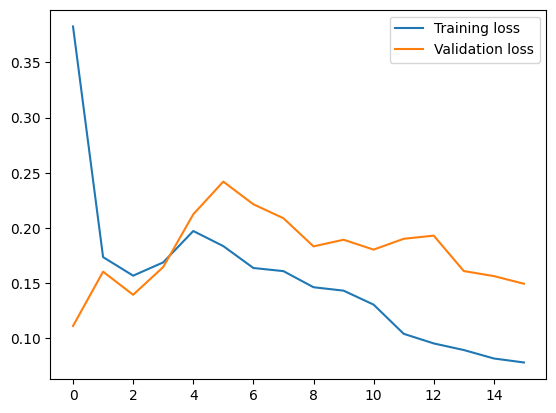

In [11]:
detector = AnomalyDetector(config, X_train, X_test)
detector.fit()  


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step
Max Train MAE: 0.26163045335364243, 90th Percentile Train MAE: 0.13886043105002388, Three-Sigma Threshold: 0.24651745385575652
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


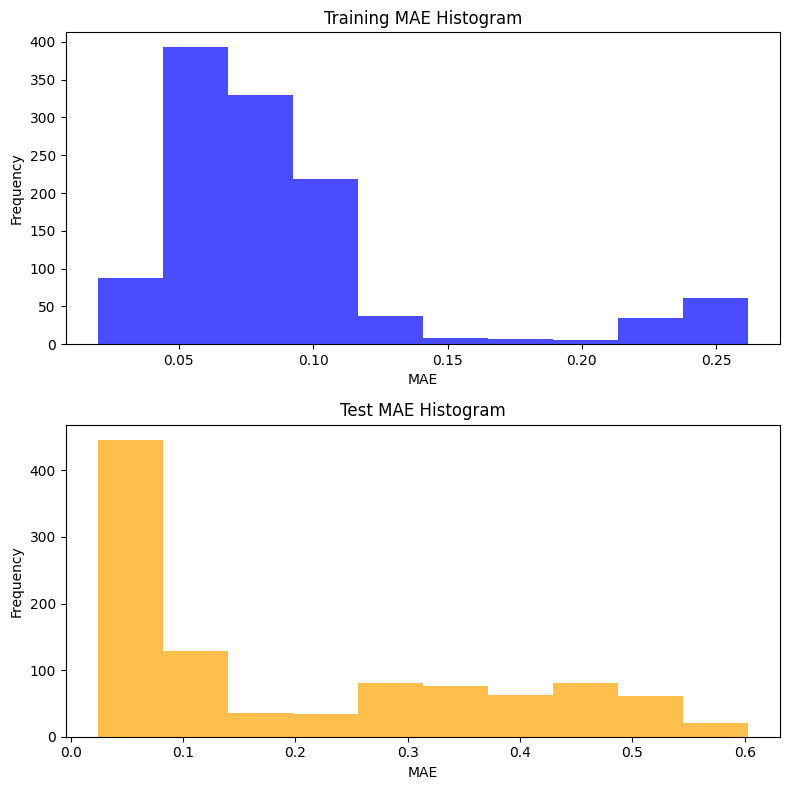

In [12]:
train_mae, test_mae, predicted_anomalies, threshold = detector.predict()

### Analysis of the predicted anomalies

In [13]:
def visualize_anomalies(
    X_test: np.ndarray,
    test_mae: np.ndarray, 
    predicted_anomalies: np.ndarray, 
    threshold: float,
    config: Config):
    """
    Visualize the distribution of reconstruction errors and highlight the detected anomalies.
    :param test_mae: Numpy array of reconstruction errors for the test set
    :param predicted_anomalies: Numpy array of boolean values indicating which sequences are predicted as anomalies
    :param threshold: The threshold used to identify anomalies
    :param config: Config object containing the original data and date information for plotting
    """
    test_data_df = data_df.copy()
    test_data_df['Date'] = test_data_df.index
    filter_start_date = pd.to_datetime(config.test_start_date)
    test_data_score_df = test_data_df[test_data_df['Date'] >= filter_start_date]
    test_data_score_df = test_data_score_df.reset_index(drop=True)
    selected_test_data_score_df = test_data_score_df.iloc[config.sequence_length:]
    selected_test_data_score_df['loss'] = test_mae
    selected_test_data_score_df['threshold'] = threshold
    selected_test_data_score_df['anomaly'] = selected_test_data_score_df['loss'] > selected_test_data_score_df['threshold']    

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=selected_test_data_score_df['Date'], y=selected_test_data_score_df['loss'], name='Test loss'))
    fig.add_trace(go.Scatter(x=selected_test_data_score_df['Date'], y=selected_test_data_score_df['threshold'], name='Threshold'))
    fig.update_layout(showlegend=True, title='Test loss vs. Threshold')
    fig.show()
    return test_data_score_df, selected_test_data_score_df
    

In [14]:
test_data_df, selected_test_data_score_df = visualize_anomalies(X_test, test_mae, predicted_anomalies, threshold, config)

C:\Users\ADE\AppData\Local\Temp\ipykernel_24748\1080759600.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_data_score_df['loss'] = test_mae
C:\Users\ADE\AppData\Local\Temp\ipykernel_24748\1080759600.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_data_score_df['threshold'] = threshold
C:\Users\ADE\AppData\Local\Temp\ipykernel_24748\1080759600.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [15]:
#test_data_df.head()  
selected_test_data_score_df.head()


Price,Close,High,Low,Open,Volume,Date,loss,threshold,anomaly
Ticker,APA,APA,APA,APA,APA,,,,
30,23.562132,24.182187,23.458788,24.156351,4292300,2020-02-14,0.086845,0.246517,False
31,24.208021,24.302751,23.209042,23.295160,2974600,2020-02-18,0.085212,0.246517,False
32,24.518049,24.698900,24.087455,24.457766,2951100,2020-02-19,0.083268,0.246517,False
33,24.612785,25.155334,24.492219,24.621397,2347000,2020-02-20,0.085551,0.246517,False
34,24.457767,24.526663,23.699922,24.233858,3148500,2020-02-21,0.088602,0.246517,False


#### Visualize the detected anomalies

In [16]:
def plot_anomalies(
        test_data_results_df: pd.DataFrame = selected_test_data_score_df, 
        config: Config = config):
    """
    Plot the actual close price and highlight the detected anomalies on the time series.
    :param test_data_results_df: DataFrame containing the test data with anomaly scores and flags
    :param config: Config object containing the original data and date information for plotting 
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot the actual close price with Date on X-axis
    ax.plot(test_data_results_df["Date"], test_data_results_df["Close"], label='Actual Price', alpha=0.7, linewidth=2, color='blue')
    
    # Get anomaly points and overlay them
    anomalies = test_data_results_df[test_data_results_df['anomaly'] == True]
    ax.scatter(anomalies["Date"], anomalies["Close"], color='red', label='Anomaly', s=100, zorder=5, marker='o')
    
    # Add COVID-19 start date vertical line
    covid_date = pd.to_datetime(config.covidemic_start_date)
    ax.axvline(x=covid_date, color='orange', linestyle='--', linewidth=2, label='COVID-19 Start')
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Close Price ($)', fontsize=12)
    ax.set_title(f"Anomaly Detection for {config.ticker} (Post-Covid Period)", fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

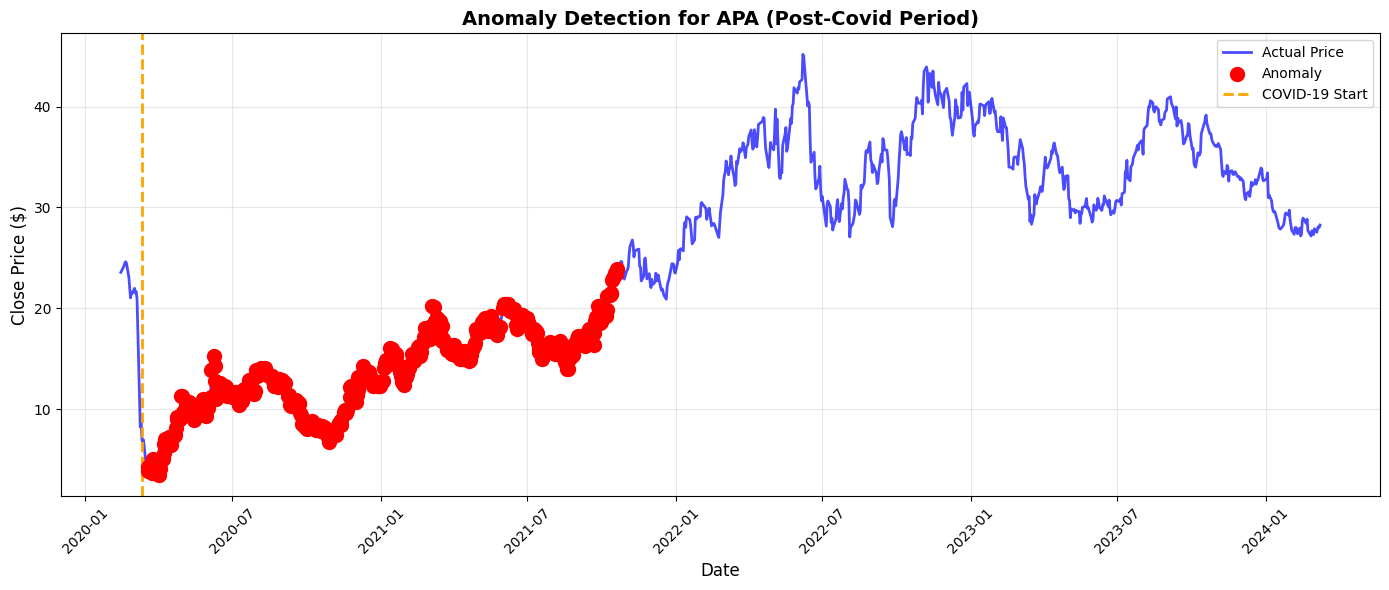

In [17]:
plot_anomalies()

In [18]:
# def plot_anomalies(
#         test_data_results_df: pd.DataFrame = selected_test_data_score_df, 
#         config: Config = config):
#     """
#     Plot the actual close price and highlight the detected anomalies on the time series.
#     :param test_data_results_df: DataFrame containing the test data with anomaly scores and flags
#     :param config: Config object containing the original data and date information for plotting 
#     """
#     plt.figure(figsize=(12, 6))
#     plt.plot(test_data_results_df["Close"], label='Actual Price', alpha=0.7)
#     anomaly_indices = np.where(test_data_results_df['anomaly'])[0]
#     plt.scatter(anomaly_indices, test_data_results_df["Close"][config.sequence_length:].iloc[anomaly_indices], color='red', label='Anomaly')
#     plt.title(f"Anomaly Detection for {config.ticker} (Post-Covid Period)")
#     plt.legend()
#     plt.show()